# Reproducing `fire_los_recovery` — 3. The catalog-noise arm

**Goal.** Re-derive the noisy-LOS experiment — Donlon+2025 catalog noise
injected into the FIRE truth, 9 settings × 2 modes (+ a 3D reference) ×
n-grid {50, 100, 200, 500} × 3 trials, 228 models — and validate **all 684
rows** against the frozen
`experiments/fire_los_recovery/results_noise_vmap/results.csv`
(2026-07-29). Companion reading: `clean_experiments/noisy_data/GUIDE_*.md`
(the machinery is copied from there — it is truth-agnostic).

**The noise model.** Pulsar-timing errors are ABSOLUTE (they don't scale
with signal) and live along the sightline:
`a_noisy = a + ε n̂`, ε ~ N(0, σ), so the LOS projection gains exactly ε.
σ's come from the 51 real Donlon+2025 per-pulsar σ(a_LOS) values — either a
constant level (`s0.5`/`s1.7`/`s4.3` = the catalog's 10th/50th/75th
percentiles) or resampled with replacement (`het`).

**The arms.** `plain` = unweighted L1; `W` = importance weights ∝ 1/σ
(whitened L1, mean-normalized); `C` = weights ∝ 1/σ² with a *squared* LOS
loss (χ²). Arms of the same family share the noise draw, so arm
comparisons are loss comparisons, never draw luck.

**Checkpoints.** ~57 models per n, ~4–6 min per n on this machine; weights
are pickled per n under `checkpoints/noise_arm/` — re-runs are
evaluation-only.

In [85]:
import csv
import importlib.util
import pickle
import time
from pathlib import Path

import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
import optax
from flax import nnx
import matplotlib.pyplot as plt

jax.config.update('jax_default_matmul_precision', 'highest')

HERE = Path.cwd()
REPO = HERE.parents[1]
EXP = REPO / 'experiments' / 'fire_los_recovery'
TRUTH = EXP / 'cache' / 'truth_old1gyr.npz'
CKPT_DIR = HERE / 'checkpoints' / 'noise_arm'
CKPT_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR = HERE / 'results_repro'
OUT_DIR.mkdir(exist_ok=True)


def _load(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

fd = _load('fire_datasets', EXP / 'datasets.py')
fn = _load('fire_noise', EXP / 'noise.py')

from galactoPINNs.models.static_model import StaticModel
from galactoPINNs.train import train_model_static
from galactoPINNs.evaluate import (cylindrical_error_decomposition,
                                   error_decomposition)

(x_pool, a_pool, x_pool_phys, cfg, val_scaled, dist_sun,
 x_obs, a_obs, val_sm, meta) = fd.build_data(TRUTH, n_val=4096)
fac = fn.sigma_scale_factor(cfg)
print(f'1 mm/s/yr = {fac:.5f} scaled acceleration units')

# smoothed-reference labels for the train pool (per-point diagnostics)
z = np.load(TRUTH)
a_pool_sm = cfg['a_transformer'].transform(jnp.asarray(z['a_pool_smooth']))

print('catalog sigmas [mm/s/yr]: median '
      f'{np.median(fn.CATALOG_SIGMAS_MMSYR):.2f}, '
      f'10th/75th pct {np.percentile(fn.CATALOG_SIGMAS_MMSYR, 10):.2f}/'
      f'{np.percentile(fn.CATALOG_SIGMAS_MMSYR, 75):.2f}')

1 mm/s/yr = 0.07890 scaled acceleration units
catalog sigmas [mm/s/yr]: median 1.69, 10th/75th pct 0.52/4.26


## Settings table and the 6-switch loss

Same table as `clean_experiments/noisy_data`: a label bundles
(noise family, arm, LOS-loss form). The per-model switch vector grows a 6th
entry `sq_on` relative to notebook 02 — it blends `|r|` vs `r²` residuals so
the χ² arm can share the same vmapped trainer — and every LOS residual is
multiplied by a per-point importance weight `w_ip` (all ones for `plain`).
The 3D reference mode (clean full vectors, `s0` only) rides along in the
no-ρ group.

In [86]:
SETTINGS = {
    's0':    ('s0',   'plain', 'l1'),
    's0.5':  ('s0.5', 'plain', 'l1'),
    's1.7':  ('s1.7', 'plain', 'l1'),
    's4.3':  ('s4.3', 'plain', 'l1'),
    'het':   ('het',  'plain', 'l1'),
    'hetW':  ('het',  'W',     'l1'),
    'hetC':  ('het',  'C',     'sq'),
    's1.7W': ('s1.7', 'W',     'l1'),
    's1.7C': ('s1.7', 'C',     'sq'),
}
MODES = ('LOS', 'LOS+Sun+rho')
REGIONS = ('sun4', 'sun15', 'gc15')
NORHO_MODES = ('LOS', '3D')
RHO_MODES = ('LOS+Sun+rho',)
LAMBDA_REL, EPS = 1.0, 1e-10


def switch_row(mode, los_loss, lambda_sun, lambda_rho):
    sq = 1.0 if los_loss == 'sq' else 0.0
    return {'3D':          (1.0, 0.0, 0.0, 0.0,        0.0,        0.0),
            'LOS':         (0.0, 1.0, 0.0, 0.0,        0.0,        sq),
            'LOS+Sun+rho': (0.0, 1.0, 1.0, lambda_sun, lambda_rho, sq)}[mode]


def make_ensemble_fns(graphdef, rest, x_obs, a_obs, tx, epochs):
    def data_terms(m, x, a, nv, w_ip, sw):
        w3d, wlos, anch_on, lam_anchor, _, sq_on = sw
        a_pred = m(x)['acceleration']
        dn = jnp.linalg.norm(a_pred - a, axis=1)
        tn = jnp.linalg.norm(a, axis=1)
        loss3d = jnp.mean(w_ip * (dn + LAMBDA_REL * dn / (tn + EPS)))
        r = jnp.sum(a_pred * nv, axis=1) - jnp.sum(a * nv, axis=1)
        perlos = w_ip * ((1.0 - sq_on) * jnp.abs(r) + sq_on * r ** 2)
        ar = (m(x_obs)['acceleration'] - a_obs).reshape(-1)
        anch = (1.0 - sq_on) * jnp.abs(ar) + sq_on * ar ** 2
        denom = x.shape[0] + anch_on * anch.size
        loss_los = (jnp.sum(perlos)
                    + anch_on * lam_anchor * jnp.sum(anch)) / denom
        return w3d * loss3d + wlos * loss_los

    def loss_norho(params, x, a, nv, w_ip, sw):
        m = nnx.merge(graphdef, params, rest)
        return data_terms(m, x, a, nv, w_ip, sw)

    def loss_rho(params, x, a, nv, w_ip, sw, colloc):
        m = nnx.merge(graphdef, params, rest)
        lap = m.compute_laplacian(colloc)
        return data_terms(m, x, a, nv, w_ip, sw) + sw[4] * jnp.mean(
            jax.nn.relu(-lap))

    def make_trainer(loss_fn):
        @jax.jit
        def train_group(params, opt, *arrays):
            def stepf(carry, _):
                p, o = carry
                losses, grads = jax.vmap(jax.value_and_grad(loss_fn))(p, *arrays)
                updates, o = tx.update(grads, o, p)
                return (optax.apply_updates(p, updates), o), losses
            (p, _), hist = jax.lax.scan(stepf, (params, opt), None,
                                        length=epochs)
            return p, hist[-1]
        return train_group

    @jax.jit
    def eval_shared(params, x_val):
        def one(p, xv):
            return nnx.merge(graphdef, p, rest)(xv)['acceleration']
        return jax.vmap(one, in_axes=(0, None))(params, x_val)

    @jax.jit
    def eval_permodel(params, X):
        def one(p, xi):
            return nnx.merge(graphdef, p, rest)(xi)['acceleration']
        return jax.vmap(one, in_axes=(0, 0))(params, X)

    return (make_trainer(loss_norho), make_trainer(loss_rho),
            eval_shared, eval_permodel)


def stack_states(states):
    return jax.tree.map(lambda *xs: jnp.stack(xs), *states)


def take_member(stacked, i):
    return jax.tree.map(lambda x: x[i], stacked)

## Self-test

Five (setting, mode) probes trained both ways — the batched trainer vs
`train_model_static` with `los_loss` / `importance_weight` kwargs (the src
API that `clean_experiments/noisy_data` upstreamed). Same contract as
`run_noise_vmap.py --self-test`, which PASSED on 2026-07-29.

In [87]:
n_st, epochs_st, lam, trial = 40, 40, 1.0, 0
rng = np.random.default_rng(trial)
idx = rng.choice(x_pool.shape[0], size=n_st, replace=False)
x_n, a_n = x_pool[idx], a_pool[idx]
dx = x_pool_phys[idx] - fd.OBSERVER
nv = jnp.asarray(dx / np.linalg.norm(dx, axis=1, keepdims=True))
colloc = fd.sample_colloc_scaled(jr.PRNGKey(1000 + trial), 64, 0.5, 25.0,
                                 cfg['x_transformer'])
check = [('s1.7', 'LOS'), ('s1.7', 'LOS+Sun+rho'),
         ('s1.7W', 'LOS'), ('hetC', 'LOS+Sun+rho'), ('s0', '3D')]


def spec_data(label, n, trial):
    family, arm, los_loss = SETTINGS[label]
    sig_i = fn.draw_sigmas_mmsyr(
        np.random.default_rng(9000 + 137 * trial + n), n, family)
    eps_rng = np.random.default_rng(
        7000 + 1009 * trial + 31 * n + fn.NOISE_FAMILY_SEED[family])
    a_noisy = fn.apply_los_noise(eps_rng, a_n, nv, sig_i * fac)
    w = fn.arm_weights(sig_i, arm)
    return los_loss, a_noisy, (jnp.ones(n) if w is None else w), sig_i


template = StaticModel(cfg, rngs=nnx.Rngs(0))
graphdef, params0, rest = nnx.split(template, nnx.Param, ...)
tx = optax.adam(1e-3)
tn_st, tr_st, _, _ = make_ensemble_fns(graphdef, rest, x_obs, a_obs, tx,
                                       epochs_st)
results_st = {}
for modes, trainer, needs_rho in ((NORHO_MODES, tn_st, False),
                                  (RHO_MODES, tr_st, True)):
    specs = [(l, mo) for (l, mo) in check if mo in modes]
    if not specs:
        continue
    A, NV, WIP, SW = [], [], [], []
    for label, mode in specs:
        los_loss, a_noisy, w_ip, _ = spec_data(label, n_st, trial)
        A.append(a_noisy if mode != '3D' else a_n)
        NV.append(nv); WIP.append(w_ip)
        SW.append(switch_row(mode, los_loss, lam, lam))
    X = jnp.stack([x_n] * len(specs))
    arrays = (X, jnp.stack(A), jnp.stack(NV), jnp.stack(WIP),
              jnp.asarray(SW, dtype=jnp.float32))
    if needs_rho:
        arrays = arrays + (jnp.stack([colloc] * len(specs)),)
    params = stack_states([params0] * len(specs))
    trained, _ = trainer(params, tx.init(params), *arrays)
    jax.block_until_ready(trained)
    for i, s in enumerate(specs):
        results_st[s] = (trained, i)

for label, mode in check:
    los_loss, a_noisy, w_ip, _ = spec_data(label, n_st, trial)
    weights = None if SETTINGS[label][1] == 'plain' else w_ip
    kw = {'3D': dict(),
          'LOS': dict(n_vecs=nv, line_of_sight=True, los_loss=los_loss,
                      importance_weight=weights),
          'LOS+Sun+rho': dict(n_vecs=nv, line_of_sight=True,
                              los_loss=los_loss, importance_weight=weights,
                              anchor_x=x_obs, anchor_a=a_obs,
                              lambda_anchor=lam, colloc_x=colloc,
                              lambda_rho=lam)}[mode]
    model = StaticModel(cfg, rngs=nnx.Rngs(0))
    train_model_static(model, optax.adam(1e-3), x_n,
                       a_n if mode == '3D' else a_noisy, epochs_st,
                       log_every=0, **kw)
    _, p_seq, _ = nnx.split(model, nnx.Param, ...)
    stacked, i = results_st[(label, mode)]
    p_vmap = take_member(stacked, i)
    num = sum(float(jnp.sum((a - b) ** 2)) for a, b in
              zip(jax.tree.leaves(p_seq), jax.tree.leaves(p_vmap)))
    den = sum(float(jnp.sum(a ** 2)) for a in jax.tree.leaves(p_seq))
    rel = (num / den) ** 0.5
    assert rel < 1e-4, f'{label}/{mode}: {rel:.2e}'
    print(f'{label:6s} {mode:12s} param reldiff: {rel:.2e}  ok')
print('self-test PASSED')

s1.7   LOS          param reldiff: 4.98e-08  ok
s1.7   LOS+Sun+rho  param reldiff: 5.64e-08  ok
s1.7W  LOS          param reldiff: 4.98e-08  ok
hetC   LOS+Sun+rho  param reldiff: 5.76e-08  ok
s0     3D           param reldiff: 6.72e-08  ok
self-test PASSED


## The sweep, checkpointed, validated per n

Seeding protocol (all frozen-identical): trial subsets `default_rng(trial)`;
σ draws `default_rng(9000 + 137·trial + n)`; noise ε
`default_rng(7000 + 1009·trial + 31·n + family_seed)` — the family seed is
what makes arms of one family share their noise; params `nnx.Rngs(t)`;
colloc `PRNGKey(1000+t)`; adam(1e-3), 1500 epochs.

Each n is compared against the frozen rows **immediately after training**
(fail fast). Full-precision columns must match bit-exactly; the
rounded diagnostic columns (`sigma_mmsyr`, `train_chi`, `train_err_*`)
must match at their printed precision.

In [88]:
N_GRID = [50, 100, 200, 500]
TRIALS, EPOCHS = 3, 1500
settings = list(SETTINGS)

params_by_trial = [nnx.split(StaticModel(cfg, rngs=nnx.Rngs(t)),
                             nnx.Param, ...)[1] for t in range(TRIALS)]
colloc_by_trial = [fd.sample_colloc_scaled(jr.PRNGKey(1000 + t), 512, 0.5,
                                           25.0, cfg['x_transformer'])
                   for t in range(TRIALS)]
train_norho, train_rho, eval_shared, eval_permodel = make_ensemble_fns(
    graphdef, rest, x_obs, a_obs, tx, EPOCHS)

x_tf = cfg['x_transformer']
val_geom = {}
for name in REGIONS:
    x_val, _ = val_scaled[name]
    xv_phys = np.asarray(x_tf.inverse_transform(x_val))
    dxv = xv_phys - fd.OBSERVER
    val_geom[name] = (xv_phys, jnp.asarray(
        dxv / np.linalg.norm(dxv, axis=1, keepdims=True)))

# frozen target, keyed for the per-n comparison
frozen_rows = {}
with open(EXP / 'results_noise_vmap' / 'results.csv') as f:
    for r in csv.DictReader(f):
        key = (int(r['n_samples']), int(r['trial']), r['setting'],
               r['mode'], r['region'])
        frozen_rows[key] = r
FULLPREC = ('rel_err', 'rel_los', 'rel_trv', 'rel_R', 'rel_z', 'rel_phi',
            'rel_err_sm', 'rel_los_sm', 'rel_trv_sm')
ROUNDED = ('sigma_mmsyr', 'train_chi', 'train_err_true_mmsyr',
           'train_err_smooth_mmsyr')


def make_specs(modes, trials):
    out = []
    for trial in range(trials):
        for label in settings:
            for mode in MODES:
                if mode in modes:
                    out.append((trial, label, mode))
            if '3D' in modes and label == 's0':
                out.append((trial, 's0', '3D'))
    return out


all_rows = []
for n in N_GRID:
    geom, noise = {}, {}
    for trial in range(TRIALS):
        rng = np.random.default_rng(trial)
        idx = rng.choice(x_pool.shape[0], size=n, replace=False)
        x_n, a_n = x_pool[idx], a_pool[idx]
        dx = x_pool_phys[idx] - fd.OBSERVER
        nv = jnp.asarray(dx / np.linalg.norm(dx, axis=1, keepdims=True))
        geom[trial] = (x_n, a_n, nv, jnp.sum(a_n * nv, axis=1),
                       jnp.sum(a_pool_sm[idx] * nv, axis=1))
        for label in settings:
            family, arm, los_loss = SETTINGS[label]
            sig_i = fn.draw_sigmas_mmsyr(
                np.random.default_rng(9000 + 137 * trial + n), n, family)
            eps_rng = np.random.default_rng(
                7000 + 1009 * trial + 31 * n + fn.NOISE_FAMILY_SEED[family])
            a_noisy = fn.apply_los_noise(eps_rng, a_n, nv, sig_i * fac)
            wgt = fn.arm_weights(sig_i, arm)
            noise[(trial, label)] = (sig_i, a_noisy,
                                     jnp.ones(n) if wgt is None else wgt,
                                     los_loss)

    ck = CKPT_DIR / f'n{n}.pkl'
    if ck.exists():
        with open(ck, 'rb') as fh:
            bundles = pickle.load(fh)
        print(f'n={n}: loaded checkpoint')
    else:
        bundles = []
        for modes, trainer, needs_rho in ((NORHO_MODES, train_norho, False),
                                          (RHO_MODES, train_rho, True)):
            specs = make_specs(modes, TRIALS)
            X, A, NV, WIP, SW, COL, P = [], [], [], [], [], [], []
            for (trial, label, mode) in specs:
                x_n, a_n, nv, _, _ = geom[trial]
                sig_i, a_noisy, w_ip, los_loss = noise[(trial, label)]
                X.append(x_n)
                A.append(a_n if mode == '3D' else a_noisy)
                NV.append(nv)
                WIP.append(jnp.ones(n) if mode == '3D' else w_ip)
                SW.append(switch_row(mode,
                                     los_loss if mode != '3D' else 'l1',
                                     1.0, 1.0))
                COL.append(colloc_by_trial[trial])
                P.append(params_by_trial[trial])
            arrays = (jnp.stack(X), jnp.stack(A), jnp.stack(NV),
                      jnp.stack(WIP), jnp.asarray(SW, dtype=jnp.float32))
            if needs_rho:
                arrays = arrays + (jnp.stack(COL),)
            params = stack_states(P)
            t0 = time.time()
            trained, _ = trainer(params, tx.init(params), *arrays)
            jax.block_until_ready(trained)
            print(f'n={n}: trained {len(specs)} models '
                  f"[{'+'.join(modes)}] in {time.time()-t0:.1f}s", flush=True)
            bundles.append({'state': jax.tree.map(np.asarray, trained),
                            'specs': specs})
        with open(ck, 'wb') as fh:
            pickle.dump(bundles, fh)

    # ---- evaluate + emit + compare this n ----
    results_n = {}
    for b in bundles:
        stacked = jax.tree.map(jnp.asarray, b['state'])
        X = jnp.stack([geom[t][0] for (t, _, _) in b['specs']])
        a_tr = eval_permodel(stacked, X)
        region_pred = {}
        for region in REGIONS:
            x_val, _ = val_scaled[region]
            apred = eval_shared(stacked, x_val)
            region_pred[region] = apred
        for i, spec in enumerate(b['specs']):
            results_n[spec] = (a_tr[i],
                               {reg: region_pred[reg][i] for reg in REGIONS})

    nbad = 0
    for trial in range(TRIALS):
        x_n, a_n, nv, a_los_true, a_los_sm = geom[trial]
        for label in settings:
            sig_i, a_noisy, w_ip, los_loss = noise[(trial, label)]
            sig_scaled = jnp.asarray(sig_i) * fac
            _, arm, _ = SETTINGS[label]
            for mode in list(MODES) + (['3D'] if label == 's0' else []):
                a_pred_tr, preds = results_n[(trial, label, mode)]
                a_tgt = a_n if mode == '3D' else a_noisy
                los_pred = jnp.sum(a_pred_tr * nv, axis=1)
                los_obs = jnp.sum(a_tgt * nv, axis=1)
                chi = (float(jnp.mean(jnp.abs(los_pred - los_obs)
                                      / sig_scaled))
                       if sig_i.max() > 0 else float('nan'))
                err_true = float(jnp.mean(jnp.abs(los_pred - a_los_true))) / fac
                err_sm = float(jnp.mean(jnp.abs(los_pred - a_los_sm))) / fac
                for region in REGIONS:
                    x_val, a_val = val_scaled[region]
                    xv_phys, nhat = val_geom[region]
                    a_pred = preds[region]
                    d = error_decomposition(a_val, a_pred, nhat)
                    dsm = error_decomposition(val_sm[region], a_pred, nhat)
                    c = cylindrical_error_decomposition(
                        a_val, a_pred, jnp.asarray(xv_phys))
                    row = dict(
                        n_samples=n, trial=trial, setting=label,
                        sigma_mmsyr=f'{np.median(sig_i):.2f}', arm=arm,
                        mode=mode, region=region,
                        rel_err=float(jnp.mean(d['rel_error_magnitude'])),
                        rel_los=float(jnp.mean(d['rel_los_error'])),
                        rel_trv=float(jnp.mean(d['rel_transverse_error'])),
                        rel_R=float(jnp.mean(c['rel_R_error'])),
                        rel_z=float(jnp.mean(c['rel_z_error'])),
                        rel_phi=float(jnp.mean(c['rel_phi_error'])),
                        rel_err_sm=float(jnp.mean(dsm['rel_error_magnitude'])),
                        rel_los_sm=float(jnp.mean(dsm['rel_los_error'])),
                        rel_trv_sm=float(jnp.mean(dsm['rel_transverse_error'])),
                        train_chi=f'{chi:.3f}',
                        train_err_true_mmsyr=f'{err_true:.3f}',
                        train_err_smooth_mmsyr=f'{err_sm:.3f}')
                    all_rows.append(row)
                    fz = frozen_rows[(n, trial, label, mode, region)]
                    bad = any(row[k] != float(fz[k]) for k in FULLPREC)
                    bad |= any(str(row[k]) != fz[k] for k in ROUNDED)
                    nbad += bad
    status = 'MATCH' if nbad == 0 else f'{nbad} MISMATCHES'
    print(f'n={n}: compared vs frozen -> {status}')
    assert nbad == 0, f'n={n}: drifted from frozen results'
print(f'all {len(all_rows)} rows match the frozen noise results ✓')

with open(OUT_DIR / 'results_noise.csv', 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=list(all_rows[0].keys()))
    w.writeheader(); w.writerows(all_rows)
print('wrote', OUT_DIR / 'results_noise.csv')

n=50: loaded checkpoint
n=50: compared vs frozen -> MATCH
n=100: loaded checkpoint
n=100: compared vs frozen -> MATCH
n=200: loaded checkpoint
n=200: compared vs frozen -> MATCH
n=500: loaded checkpoint
n=500: compared vs frozen -> MATCH
all 684 rows match the frozen noise results ✓
wrote /Users/pablom.perez/Desktop/Linas-group/galactoPINNs/clean_experiments/fire_sims/results_repro/results_noise.csv


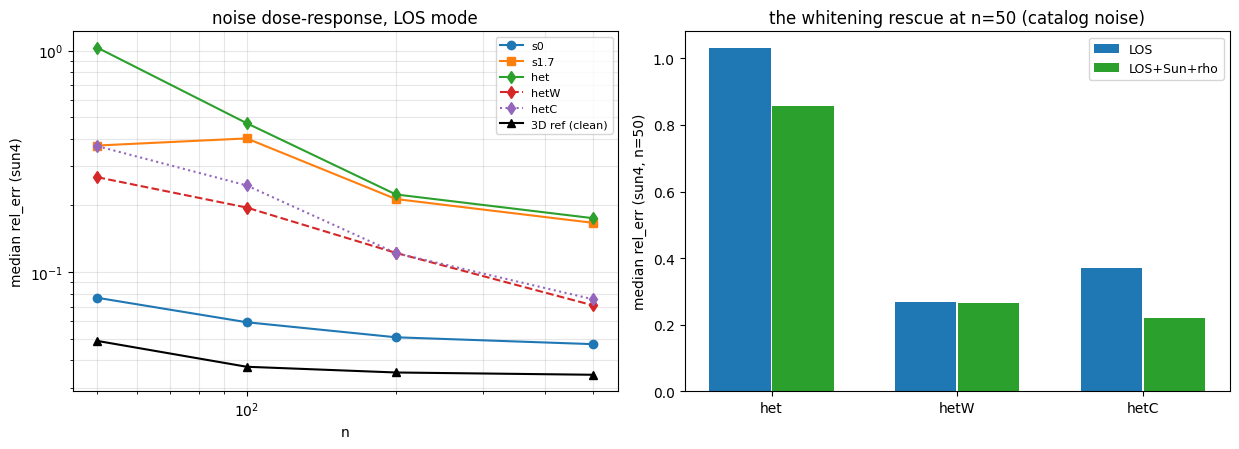

In [89]:
import collections

med = collections.defaultdict(dict)
for r in all_rows:
    if r['region'] == 'sun4':
        med[(r['setting'], r['mode'])].setdefault(
            r['n_samples'], []).append(r['rel_err'])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
ax = axes[0]
for setting, style in [('s0', 'o-'), ('s1.7', 's-'), ('het', 'd-'),
                       ('hetW', 'd--'), ('hetC', 'd:')]:
    vals = med[(setting, 'LOS')]
    ns = sorted(vals)
    ax.plot(ns, [np.median(vals[n]) for n in ns], style, label=f'{setting}')
vals3d = med[('s0', '3D')]
ax.plot(sorted(vals3d), [np.median(vals3d[n]) for n in sorted(vals3d)],
        'k^-', label='3D ref (clean)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('n'); ax.set_ylabel('median rel_err (sun4)')
ax.set_title('noise dose-response, LOS mode')
ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=8)

ax = axes[1]
n0 = 50
labels = ['het', 'hetW', 'hetC']
for mode, off, color in [('LOS', -0.17, 'C0'), ('LOS+Sun+rho', 0.17, 'C2')]:
    vals = [np.median(med[(s, mode)][n0]) for s in labels]
    ax.bar(np.arange(3) + off, vals, width=0.33, color=color, label=mode)
ax.set_xticks(range(3), labels)
ax.set_ylabel(f'median rel_err (sun4, n={n0})')
ax.set_title('the whitening rescue at n=50 (catalog noise)')
ax.legend(fontsize=9)
fig.tight_layout()

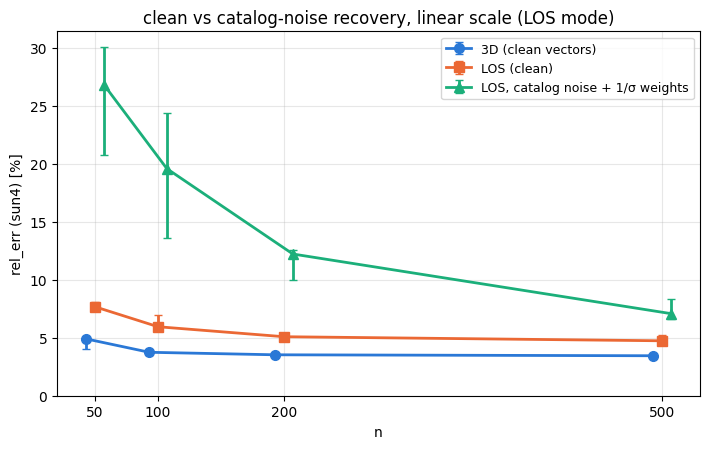

In [90]:
# rel_err vs n, linear axes: clean 3D vs clean LOS vs catalog noise + 1/sigma
# marker = median over the 3 trials, error bar = min-max across trials
SEL = [(('s0', '3D'), '3D (clean vectors)', '#2a78d6', 'o', -7),
       (('s0', 'LOS'), 'LOS (clean)', '#eb6834', 's', 0),
       (('hetW', 'LOS'), 'LOS, catalog noise + 1/σ weights', '#1baf7a', '^', 7)]
curves = {key: {} for key, _, _, _, _ in SEL}
for r in all_rows:
    key = (r['setting'], r['mode'])
    if r['region'] == 'sun4' and key in curves:
        curves[key].setdefault(r['n_samples'], []).append(100 * r['rel_err'])

fig, ax = plt.subplots(figsize=(7.2, 4.6))
for key, label, color, marker, dodge in SEL:
    ns = np.array(sorted(curves[key]))
    v = np.array([curves[key][n] for n in ns])
    med = np.median(v, axis=1)
    yerr = np.stack([med - v.min(axis=1), v.max(axis=1) - med])
    ax.errorbar(ns + dodge, med, yerr=yerr, fmt=marker + '-', color=color,
                lw=2, ms=7, capsize=3, label=label)
ax.set_xlabel('n')
ax.set_ylabel('rel_err (sun4) [%]')
ax.set_title('clean vs catalog-noise recovery, linear scale (LOS mode)')
ax.set_xticks(N_GRID)
ax.set_ylim(bottom=0)
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
fig.tight_layout()

## Wrap-up

All 684 rows of the frozen noise-arm results reproduce. The physics story
they encode: plain L1 collapses under catalog noise at n=50 (~100%
error), 1/σ whitening rescues most of it (~26%), χ² weighting is close
behind, and by n=500 every arm converges to ~7% — while the 3D clean
reference shows what noise-free full vectors would buy. Next:
`04_density_rho_dm.ipynb`, where these same trained settings become the
ρ_DM,☉ error budget.

---
# Addendum (2026-08-09, revised 2026-08-11) — stopping rules + a real-data-legal scaling

The architecture-ladder experiment with a **simulation-fitted BFE baseline**
(`experiments/fire_los_recovery/run_arch_bfe_vmap.py`; n,l ≤ 4
Hernquist–Ostriker expansion fit to the m12i particles) exposed a protocol
bug in everything above: **1500 epochs is not a neutral choice — it is an
implicit early-stopping rule** calibrated for one scaling only. Fixing it
surfaced a second, quieter problem: the scaling itself was
truth-derived — `scale_data` set u\* = max|u_true| (plain) or
u\* = max|u_true − u_baseline| (residual), quantities no MW observation
provides.

**Revised protocol — u\* declared a priori** (`u_star_override`, one fixed
rule, nothing per-simulation): the plain scaling uses the adopted model's
own amplitude, u\* = max|u_model| = 0.1381; residual scalings use
u\* = 0.2·max|u_baseline| (0.0404 BFE, 0.0276 NFW), with the 0.2 fixed from
the prior that MW potential models disagree at the 5–20 % level (e.g.
Ou+2025 rotation-curve systematics). For reference, the true
misspecification on m12i is 47 % (NFW — the prior *understates* it) and
3.5 % (BFE, fit to the particles themselves — an upper bound on baseline
quality with no real-MW analog; the NFW arm is the realistic case).

| scaling | u\* (a priori) | 1 mm/s/yr in scaled units | median catalog σ (1.69) |
|---|---|---|---|
| plain (III) | 0.1381 | 0.116 | 0.196 |
| NFW residual (IV) | 0.0276 | 0.580 | 0.980 |
| BFE residual (IV) | 0.0404 | 0.396 | 0.669 |

The NN's target is O(1)-ish in every context, but the *noise* is fixed in
physical units — so the same 1500-epoch budget sits 3–5× deeper below the
noise floor in the residual scalings than in the plain one. That is the
protocol bug; **χ-matched stopping** (below) removes it, and also removes
any sensitivity to u\*: a paired rerun on identical seeds/noise showed the
a-priori scales reproduce the truth-derived results within trial scatter,
a deliberate 17× mis-guess shifts nothing, and even a single shared u\*
for all arms costs ≲1.5 pts (in the misspecified-NFW arm only).

**The fix: χ-matched stopping** (Morozov's *discrepancy principle*; in
astronomer dialect "stop at reduced χ² ≈ 1", here the L1 version). Because
every point's σ is *known* (catalog values), stop when the whitened train
misfit first reaches √(2/π) ≈ 0.798 — no validation holdout needed, which
matters at n = 50 where a 15 % split is 7 points of pure luck.

`experiments/fire_los_recovery/val_split_check.py` records, for each
(arch, baseline, n, trial), the full per-epoch trajectory of train-χ,
15 %-holdout-χ, and TRUE recovery error, on the *same* data/seeds as the
ladders — so every stopping rule is just a different read-off of the same
trajectory, benchmarked against the **oracle** (the epoch a clairvoyant
would pick: argmin of the true error).


### The overfitting, seen directly

One run each of the two worst LOS n=50 rows from the tables below, trained
on **all 50 points** (no holdout — this is not the real-data protocol, just
the demonstration that a fixed budget accidentally overfits): the training
loss (1/σ-weighted L1, what the hetW arm minimizes) keeps sinking over the
whole 1500-epoch budget, while the **true** relative error on the Sun-region
evaluation points (a 512-point subsample of sun4, recorded every epoch —
knowable only in simulation) bottoms out within the first ~50 epochs (dot)
and then climbs. Everything after the dot is the model fitting the noise.
The dashed vertical line marks where the χ-matched rule (next section)
would have stopped the same run using only the known catalog σ's — right at
the error minimum, with no holdout and no access to the truth.

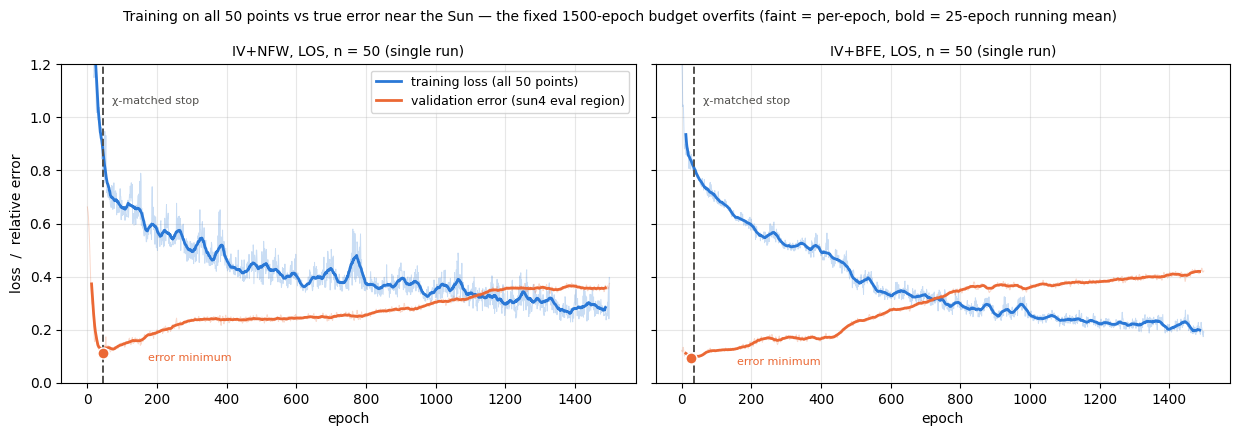

In [91]:
# train loss vs true sun4 error, one run trained on ALL 50 points (the
# `full` runs of val_split_check; per-epoch columns = loss_train, chi_val
# (dummy here), rel_err sun4-sub, rel_err sun15-sub).
# The run directory encodes (mode, baseline) — LOS-mode sources here:
TRAJ_SRC = {'IV+NFW': ('results_val_split_check_legal_nfw', 'IV'),
            'IV+BFE': ('results_val_split_check_legal', 'IV')}
N_SHOW, TRIAL = 50, 0


def smooth(y, k=25):
    return np.convolve(y, np.ones(k) / k, mode='valid')


fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4), sharey=True)
for ax, (variant, (d, arch)) in zip(axes, TRAJ_SRC.items()):
    z = np.load(EXP / d / 'trajectories.npz')
    h = z[f'full|{arch}|{N_SHOW}|{TRIAL}']
    ep = np.arange(h.shape[0])
    for col, color, lab in ((0, '#2a78d6', 'training loss (all 50 points)'),
                            (2, '#eb6834',
                             'validation error (sun4 eval region)')):
        ax.plot(ep, h[:, col], color=color, lw=0.7, alpha=0.25)
        ys = smooth(h[:, col])
        ax.plot(ep[12:12 + len(ys)], ys, color=color, lw=2, label=lab)
    below = np.flatnonzero(h[:, 0] <= float(np.sqrt(2 / np.pi)))
    if below.size:
        e_chi = int(below[0])
        ax.axvline(e_chi, color='#52514e', ls='--', lw=1.4)
        ax.annotate('χ-matched stop', (e_chi, 0), xytext=(e_chi + 25, 1.05),
                    fontsize=8, color='#52514e')
    e_min = int(np.argmin(h[:, 2]))
    ax.plot(e_min, h[e_min, 2], 'o', color='#eb6834', ms=8, mec='white',
            zorder=5)
    ax.annotate('error minimum', (e_min, h[e_min, 2]),
                xytext=(e_min + 130, h[e_min, 2] * 0.72), fontsize=8,
                color='#eb6834')
    ax.set_ylim(0, 1.2)
    ax.set_xlabel('epoch')
    ax.set_title(f'{variant}, LOS, n = {N_SHOW} (single run)', fontsize=10)
    ax.grid(alpha=0.3)
axes[0].set_ylabel('loss  /  relative error')
axes[0].legend(fontsize=9)
fig.suptitle('Training on all 50 points vs true error near the Sun — the '
             'fixed 1500-epoch budget overfits '
             '(faint = per-epoch, bold = 25-epoch running mean)', fontsize=10)
fig.tight_layout()

In [92]:
# stopping-rule tables: chi-stop vs val-split vs fixed-1500, both modes.
# summary.csv does not carry (mode, baseline) columns - the run directory
# encodes them; this mapping is the authority:
VSC_DIRS = {
    ('LOS', 'III'):            [('results_val_split_check_legal', 'III')],
    ('LOS', 'IV+NFW'):         [('results_val_split_check_legal_nfw',
                                 'IV')],
    ('LOS', 'IV+BFE'):         [('results_val_split_check_legal', 'IV')],
    ('LOS+Sun+rho', 'III'):    [('results_val_split_check_legal_rho',
                                 'III')],
    ('LOS+Sun+rho', 'IV+NFW'): [('results_val_split_check_legal_rho_nfw',
                                 'IV')],
    ('LOS+Sun+rho', 'IV+BFE'): [('results_val_split_check_legal_rho',
                                 'IV')],
}
N_VSC = (50, 200, 500)


def load_vsc(mode, variant):
    out = []
    for d, arch in VSC_DIRS[(mode, variant)]:
        p = EXP / d / 'summary.csv'
        if not p.exists():
            continue
        with open(p) as f:
            out += [r for r in csv.DictReader(f) if r['arch'] == arch]
    return out


def vsc_cell(rows, n, key):
    v = 100 * np.array([float(r[key]) for r in rows
                        if int(float(r['n'])) == n])
    if v.size == 0:
        return '     ---    '
    return f'{np.median(v):5.1f} ({v.min():2.0f}-{v.max():2.0f})'


for mode in ('LOS', 'LOS+Sun+rho'):
    print(f'== {mode} ==  sun4 recovery error [%], median (min-max), '
          f'6 trials')
    print(f'{"arm":14s} {"n":>4s} {"chi-stop":>13s} {"val-split":>13s} '
          f'{"fixed 1500":>13s}')
    for variant in ('III', 'IV+NFW', 'IV+BFE'):
        rows = load_vsc(mode, variant)
        for n in N_VSC:
            print(f'{variant:14s} {n:4d} '
                  f'{vsc_cell(rows, n, "rec4_chi_full"):>13s} '
                  f'{vsc_cell(rows, n, "rec4_val_split"):>13s} '
                  f'{vsc_cell(rows, n, "rec4_e1500"):>13s}')
    print()

== LOS ==  sun4 recovery error [%], median (min-max), 6 trials
arm               n      chi-stop     val-split    fixed 1500
III              50  13.3 (12-16)  14.4 (11-33)  22.9 (21-33)
III             200   8.9 ( 8-12)   9.9 ( 9-12)  11.2 ( 9-14)
III             500   7.6 ( 7- 8)   7.8 ( 6-16)   7.3 ( 7- 8)
IV+NFW           50  13.9 (11-16)  17.8 (11-29)  35.8 (23-55)
IV+NFW          200   9.4 ( 9-11)  10.2 ( 9-12)  12.7 (10-17)
IV+NFW          500   7.3 ( 6- 8)   7.9 ( 7- 9)   8.0 ( 8-10)
IV+BFE           50  12.0 (10-16)  13.4 (10-17)  40.9 (23-56)
IV+BFE          200   8.0 ( 7-12)   8.9 ( 7-12)  16.8 (14-22)
IV+BFE          500   7.1 ( 6-10)   7.7 ( 6-10)   9.7 ( 9-15)

== LOS+Sun+rho ==  sun4 recovery error [%], median (min-max), 6 trials
arm               n      chi-stop     val-split    fixed 1500
III              50  14.7 (12-18)  12.6 (11-25)  20.6 (14-27)
III             200   8.7 ( 8-11)   9.4 ( 8-11)  10.0 ( 9-12)
III             500   7.2 ( 6- 8)   8.1 ( 6-13)   7.1 ( 6- 

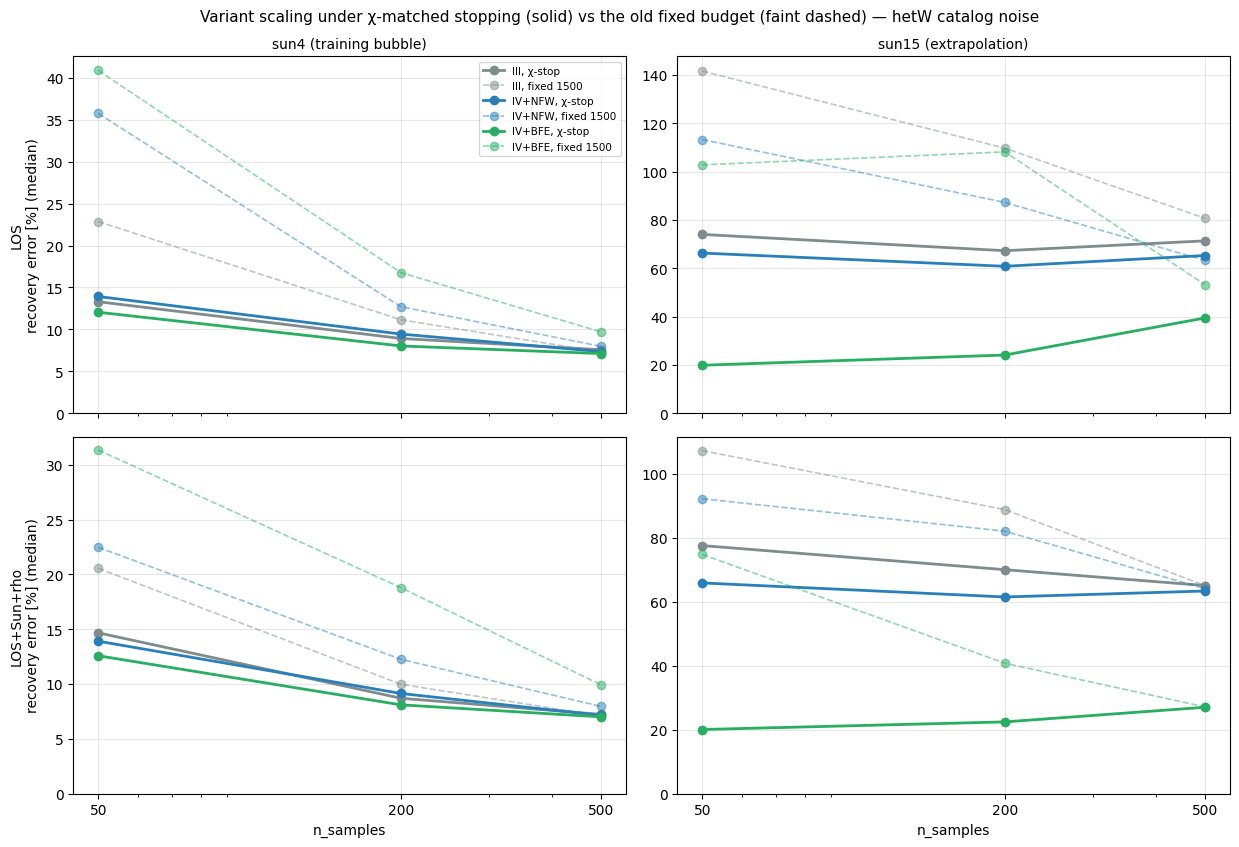

In [93]:
# error scaling of the network variants under chi-matched stopping
VARIANT_COLORS = {'III': '#7f8c8d', 'IV+NFW': '#2980b9', 'IV+BFE': '#27ae60'}
fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.6), sharex=True)
for i, mode in enumerate(('LOS', 'LOS+Sun+rho')):
    for j, (key, reg) in enumerate((('rec4', 'sun4 (training bubble)'),
                                    ('rec15', 'sun15 (extrapolation)'))):
        ax = axes[i, j]
        for variant, color in VARIANT_COLORS.items():
            rows = load_vsc(mode, variant)
            if not rows:
                continue
            med_chi = [np.median([100 * float(r[f'{key}_chi_full'])
                                  for r in rows
                                  if int(float(r['n'])) == n])
                       for n in N_VSC]
            med_e15 = [np.median([100 * float(r[f'{key}_e1500'])
                                  for r in rows
                                  if int(float(r['n'])) == n])
                       for n in N_VSC]
            ax.plot(N_VSC, med_chi, 'o-', color=color, lw=2,
                    label=f'{variant}, χ-stop')
            ax.plot(N_VSC, med_e15, 'o--', color=color, lw=1.2, alpha=0.5,
                    label=f'{variant}, fixed 1500')
        ax.set_xscale('log')
        ax.set_xticks(N_VSC)
        ax.get_xaxis().set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
        ax.grid(True, alpha=0.3)
        ax.set_ylim(bottom=0)
        if i == 0:
            ax.set_title(reg, fontsize=10)
        if i == 1:
            ax.set_xlabel('n_samples')
        if j == 0:
            ax.set_ylabel(f'{mode}\nrecovery error [%] (median)')
axes[0, 0].legend(fontsize=7.5)
fig.suptitle('Variant scaling under χ-matched stopping (solid) vs the old '
             'fixed budget (faint dashed) — hetW catalog noise', fontsize=11)
fig.tight_layout()

## Rotation curve: what the models actually know

The recovery-error numbers are abstract; the circular-velocity curve
v_c(R) = √(−R·a_R) (midplane, azimuthally averaged) is the physicist's
x-ray of the same models. The solid black curve is the truth — the same
thin-disk gc15 construction as the frozen metadata check, in 0.5-kpc
bins — and its grey band is the 16–84 % azimuthal/vertical scatter of the
true field itself: "v_c(R)" for this galaxy is only defined to that width,
so deviations inside the band are structure the field does not agree on
azimuthally. NB the azimuthal average is a *hard* test: a circle at
R = 8 kpc passes through the 4-kpc Sun bubble only near the Sun's
azimuth — most of every circle is extrapolation.

First figure: PINN III (no baseline) at n = 50, the **χ-stopped** models
(6 trials, `val_split_check` checkpoints, a-priori scaling) against the
**fixed-1500** models (this notebook's own noise-arm checkpoints, hetW
LOS+Sun+ρ, 3 trials, notebook scaling). Band = min–max over trials.
Then, all three architectures under the
same χ-matched protocol at n = 50 and n = 500, first with the pulsar
accelerations alone (LOS), then with the full protocol (LOS+Sun+ρ).


In [94]:
# --- rotation-curve setup: legal-scaling contexts, checkpoint loaders,
# and the solid truth curve. The chi-stopped checkpoints were trained in
# the a-priori scaling, so each variant is decoded with ITS OWN
# transformers (NOT this notebook's truth-derived ones).
import sys
sys.path.insert(0, str(EXP))
import astropy.units as au
import galax.potential as gpot
from bfe_baseline import DEFAULT_COEFFS, load_bfe
from run_arch_bfe_vmap import (arch_cfg_bfe, build_contexts_bfe,
                               make_model_bfe)
from datasets import HALO_RS

KMS2 = float(((au.km / au.s) ** 2).to(au.kpc ** 2 / au.Myr ** 2))

# the a-priori scales (derivation in the addendum markdown above)
U_PLAIN, U_RES_NFW, U_RES_BFE = 0.1381, 0.0276, 0.0404

bfe_pot, _, _ = load_bfe(str(DEFAULT_COEFFS))
nfw_pot = gpot.NFWPotential(m=5.4e11, r_s=HALO_RS, units='galactic')
ctx_b, _ = build_contexts_bfe(str(TRUTH), 4096, bfe_pot,
                              u_star_plain=U_PLAIN, u_star_res=U_RES_BFE)
ctx_n, _ = build_contexts_bfe(str(TRUTH), 4096, nfw_pot,
                              u_star_plain=U_PLAIN, u_star_res=U_RES_NFW)

# variant -> (arch, context, {mode: results dir}, ckpt stem, baseline pot)
VARIANT_SRC = {
    'III':    ('III', ctx_b['plain'],
               {'LOS': 'results_val_split_check_legal',
                'LOSSunrho': 'results_val_split_check_legal_rho'},
               'III_bfe', bfe_pot),
    'IV+NFW': ('IV', ctx_n['residual'],
               {'LOS': 'results_val_split_check_legal_nfw',
                'LOSSunrho': 'results_val_split_check_legal_rho_nfw'},
               'IV_nfw', nfw_pot),
    'IV+BFE': ('IV', ctx_b['residual'],
               {'LOS': 'results_val_split_check_legal',
                'LOSSunrho': 'results_val_split_check_legal_rho'},
               'IV_bfe', bfe_pot),
}
TEMPLATES = {}
for name, (arch, c, d, stem, pot) in VARIANT_SRC.items():
    cfg_v = arch_cfg_bfe(arch, c['cfg'], pot)
    gd, _, rst = nnx.split(make_model_bfe(arch, cfg_v, 0, None, 0.0,
                                          HALO_RS), nnx.Param, ...)
    TEMPLATES[name] = (gd, rst, c)


def load_states(name, n, mode='LOS', trials=6):
    dirs, stem = VARIANT_SRC[name][2], VARIANT_SRC[name][3]
    out = []
    for t in range(trials):
        p = (EXP / dirs[mode] / 'checkpoints'
             / f'{stem}_{mode}_n{n}_t{t}.pkl')
        if p.exists():
            with open(p, 'rb') as fh:
                out.append(pickle.load(fh)['state'])
    return out


R_GRID_VC = np.linspace(2.0, 14.0, 25)
PHI_VC = np.linspace(0, 2 * np.pi, 128, endpoint=False)


def model_vc_v(state, name):
    # vc(R) of one member, decoded with its own training transformers
    gd, rst, c = TEMPLATES[name]
    x_tf_v = c['cfg']['x_transformer']
    a_tf_v = c['cfg']['a_transformer']
    m = nnx.merge(gd, jax.tree.map(jnp.asarray, state), rst)
    vcs = []
    for R in R_GRID_VC:
        pts = np.stack([R * np.cos(PHI_VC), R * np.sin(PHI_VC),
                        np.zeros_like(PHI_VC)], axis=1)
        a_s = m(x_tf_v.transform(jnp.asarray(pts)))['acceleration']
        a_p = np.asarray(a_tf_v.inverse_transform(a_s))
        aR = np.mean(np.sum(a_p * (pts / R), axis=1))
        vcs.append(np.sqrt(max(-R * aR, 0.0) / KMS2))
    return np.array(vcs)


# solid truth curve: same construction as the frozen metadata check
# (thin-disk gc15 truth points), 0.5-kpc bins; band = the true field's
# own 16-84% azimuthal/vertical scatter
zt = np.load(TRUTH)
xg = np.asarray(zt['x_val|gc15'], dtype=np.float64)
ag = np.asarray(zt['a_val|gc15'])
Rg = np.hypot(xg[:, 0], xg[:, 1])
aR_t = -(ag[:, 0] * xg[:, 0] + ag[:, 1] * xg[:, 1]) / np.maximum(Rg, 1e-12)
vc_t = np.sqrt(np.maximum(Rg * aR_t, 0.0) / KMS2)
thin = np.abs(xg[:, 2]) < 1.0
edges = np.arange(2.0, 14.5, 0.5)
t_mid, t_med, t_lo, t_hi = [], [], [], []
for lo_e, hi_e in zip(edges[:-1], edges[1:]):
    msk = thin & (Rg >= lo_e) & (Rg < hi_e)
    if msk.sum() >= 5:
        t_mid.append(0.5 * (lo_e + hi_e))
        t_med.append(np.median(vc_t[msk]))
        t_lo.append(np.percentile(vc_t[msk], 16))
        t_hi.append(np.percentile(vc_t[msk], 84))
print({k: len(load_states(k, 50)) for k in VARIANT_SRC},
      'LOS checkpoints found @ n=50')


{'III': 6, 'IV+NFW': 6, 'IV+BFE': 6} LOS checkpoints found @ n=50


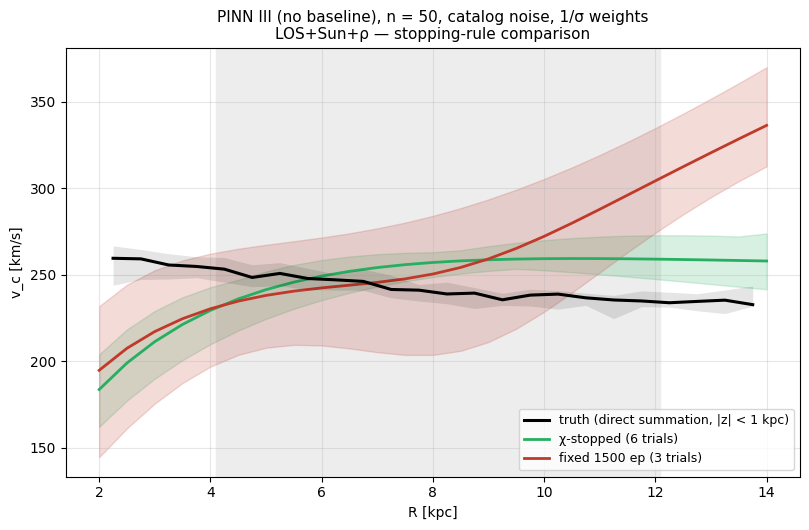

In [95]:
# chi-stopped members (legal-scaling val_split_check checkpoints) vs the
# fixed-1500 members (this notebook's own noise-arm bundles) - III, n=50
vc_chi = np.array([model_vc_v(st, 'III')
                   for st in load_states('III', 50, 'LOSSunrho')])


def model_vc_nb(member_state):
    # fixed-1500 members were trained in THIS notebook's (plain,
    # truth-derived) scaling - decode with the notebook's transformers
    m = nnx.merge(graphdef, jax.tree.map(jnp.asarray, member_state), rest)
    vcs = []
    for R in R_GRID_VC:
        pts = np.stack([R * np.cos(PHI_VC), R * np.sin(PHI_VC),
                        np.zeros_like(PHI_VC)], axis=1)
        a_s = m(x_tf.transform(jnp.asarray(pts)))['acceleration']
        a_p = np.asarray(cfg['a_transformer'].inverse_transform(a_s))
        aR = np.mean(np.sum(a_p * (pts / R), axis=1))
        vcs.append(np.sqrt(max(-R * aR, 0.0) / KMS2))
    return np.array(vcs)


with open(CKPT_DIR / 'n50.pkl', 'rb') as fh:
    bundles50 = pickle.load(fh)
vc_e1500 = []
for b_ in bundles50:
    for i, spec in enumerate(b_['specs']):
        if spec[1] == 'hetW' and spec[2] == 'LOS+Sun+rho':
            vc_e1500.append(model_vc_nb(
                jax.tree.map(lambda x: x[i], b_['state'])))
vc_e1500 = np.array(vc_e1500)

fig, ax = plt.subplots(figsize=(8.2, 5.4))
ax.plot(t_mid, t_med, 'k-', lw=2.2, zorder=5,
        label='truth (direct summation, |z| < 1 kpc)')
ax.fill_between(t_mid, t_lo, t_hi, color='k', alpha=0.10, zorder=4, lw=0)
for vc_set, color, lab in ((vc_chi, '#27ae60', 'χ-stopped (6 trials)'),
                           (vc_e1500, '#c0392b',
                            'fixed 1500 ep (3 trials)')):
    if vc_set.size == 0:
        continue
    ax.plot(R_GRID_VC, vc_set.mean(0), '-', color=color, lw=2, label=lab)
    ax.fill_between(R_GRID_VC, vc_set.min(0), vc_set.max(0), color=color,
                    alpha=0.18)
ax.axvspan(4.10, 12.08, color='0.93', zorder=0)
ax.set_xlabel('R [kpc]')
ax.set_ylabel('v_c [km/s]')
ax.set_title('PINN III (no baseline), n = 50, catalog noise, 1/σ weights\n'
             'LOS+Sun+ρ — stopping-rule comparison', fontsize=11)
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc='lower right')
fig.tight_layout()


### What the baseline buys, at fixed protocol

Same construction, all three architectures under the identical χ-matched,
a-priori-scaled protocol, at n = 50 and n = 500 — **two figures**: first
in LOS mode (the pulsar accelerations alone, no Sun anchor, no ρ ≥ 0
hinge — what the sparse data by itself pins down and what the analytic
baseline contributes), then the full protocol (LOS+Sun+ρ). Bands =
min–max over the 6 trials (each trial re-rolls the pulsar draw, the σ
assignment, the noise, the init, and the collocation points).


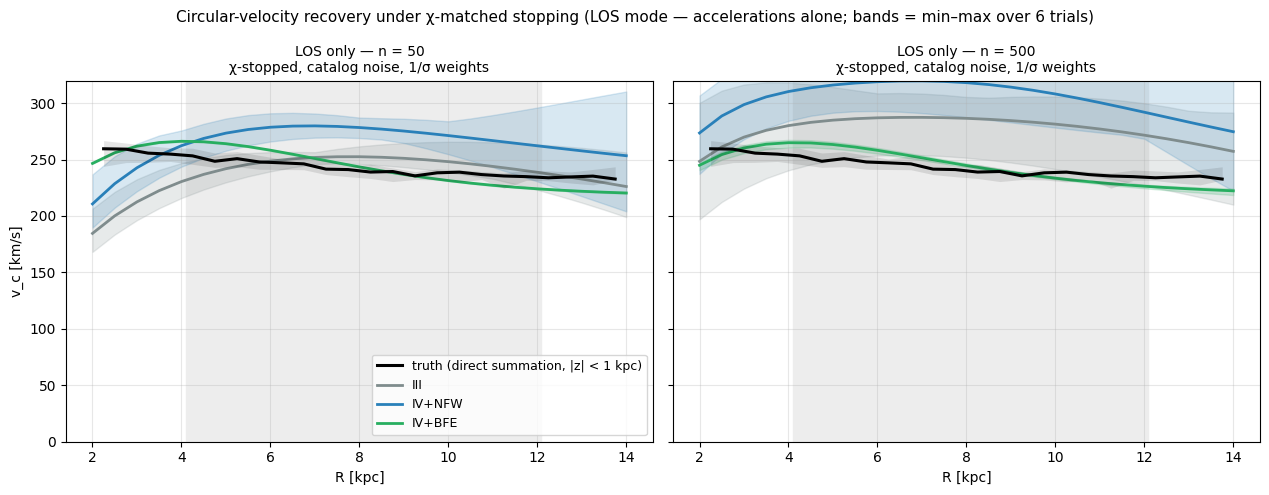

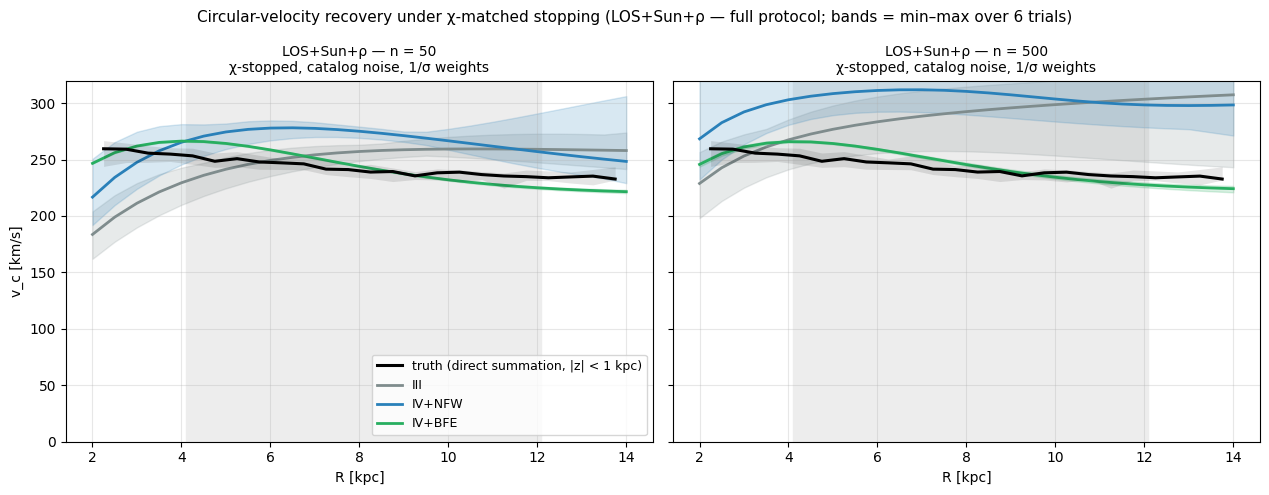

In [96]:
VARIANT_COLORS = {'III': '#7f8c8d', 'IV+NFW': '#2980b9',
                  'IV+BFE': '#27ae60'}
for mode, mode_tag, mode_label in (
        ('LOS', 'LOS only', 'LOS mode — accelerations alone'),
        ('LOSSunrho', 'LOS+Sun+ρ', 'LOS+Sun+ρ — full protocol')):
    fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.0), sharey=True)
    for ax, n in zip(axes, (50, 500)):
        ax.plot(t_mid, t_med, 'k-', lw=2.2, zorder=5,
                label='truth (direct summation, |z| < 1 kpc)')
        ax.fill_between(t_mid, t_lo, t_hi, color='k', alpha=0.10,
                        zorder=4, lw=0)
        for name, color in VARIANT_COLORS.items():
            vcs = np.array([model_vc_v(st, name)
                            for st in load_states(name, n, mode)])
            if vcs.size == 0:
                continue
            ax.plot(R_GRID_VC, vcs.mean(0), '-', color=color, lw=2,
                    label=name)
            ax.fill_between(R_GRID_VC, vcs.min(0), vcs.max(0),
                            color=color, alpha=0.18)
        ax.axvspan(4.10, 12.08, color='0.93', zorder=0)
        ax.set_xlabel('R [kpc]')
        ax.set_title(f'{mode_tag} — n = {n}\n'
                     'χ-stopped, catalog noise, 1/σ weights', fontsize=10)
        ax.grid(alpha=0.3)
        ax.set_ylim(0, 320)
    axes[0].set_ylabel('v_c [km/s]')
    axes[0].legend(fontsize=9, loc='lower right')
    fig.suptitle(f'Circular-velocity recovery under χ-matched stopping '
                 f'({mode_label}; bands = min–max over 6 trials)',
                 fontsize=11)
    fig.tight_layout()


### Addendum wrap-up

- **χ-matched stopping ≈ val-split where both work, and strictly safer**:
  ~1 pt median regret vs the oracle, no data cost, no spurious-minimum
  outliers (the val curve on 7–75 holdout points has them).
- The fixed 1500-epoch budget was an *accidental* discrepancy-principle
  stop for one scaling only — which is why the noise arm in this notebook
  (all PINN III) was never visibly hurt, while baseline-residual
  architectures were.
- **The scaling is now declared a priori** (u\* = max|u_model|; residual
  u\* = 0.2·max|u_baseline|) — nothing in the protocol touches the truth,
  and paired reruns show the χ-stopped results are insensitive to u\*
  over a 17× range (a single shared u\* for all arms costs ≲1.5 pts,
  in the misspecified-NFW arm only).
- The rotation curves make the abstraction concrete: at n = 50 the
  overtrained models run away outside the bubble (noise-fit wiggles
  masquerading as mass) while the χ-stopped models stay inside or near
  the truth's own azimuthal scatter — and the well-specified BFE baseline
  tracks the truth curve at both n: baseline quality, not n, controls the
  far field. For what these upgrades do — and pointedly do *not* do — to
  the ρ_DM,☉ extraction, see the notebook-04 addendum.


trained 6 models x 20000 epochs in 864.9s
mode         tr  min@ep  best<=1500  best>1500   @final
LOS           0      65       0.116      0.250    0.478
LOS           1      42       0.132      0.264    0.713
LOS           2     208       0.117      0.205    3.812
LOS+Sun+rho   0      55       0.114      0.194    0.449
LOS+Sun+rho   1      44       0.151      0.247    0.704
LOS+Sun+rho   2     484       0.107      0.142    0.813

grokking verdict: none — no run improves on its early validation minimum after epoch 1500; longer training only fits noise (and there is no weight decay here, the canonical grokking ingredient).


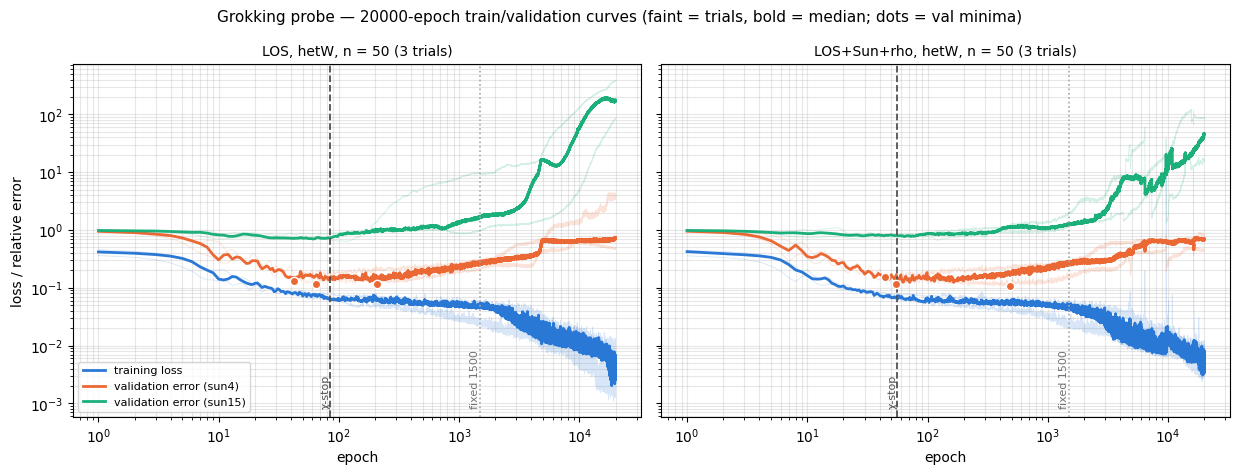

In [97]:
# Grokking probe: train 13x past the fixed budget and watch train vs
# validation error EVERY epoch. Setup = the headline noisy arm (hetW =
# catalog het noise + 1/sigma weights) at n=50, both modes, 3 trials,
# same seed/data/init protocol as the sweep above — these are the
# sweep's own runs extended to 20000 epochs. "Validation" = TRUE
# relative acceleration error on 512-point subsamples of the sun4/sun15
# truth grids (simulation-only diagnostic, same spirit as the
# val_split_check trajectories). Classic grokking = validation error
# stalls or worsens for a long stretch, then drops to a NEW minimum
# late. NB the canonical grokking setups need explicit regularization
# (weight decay) — absent here — so the +rho mode (hinge + Sun anchor)
# is the more plausible candidate. Trajectories are cached beside the
# sweep checkpoints (~15-20 min first run); re-runs are plot-only.
N_G, EPOCHS_G, TRIALS_G, LABEL_G = 50, 20000, 3, 'hetW'
MODES_G = ('LOS', 'LOS+Sun+rho')
GROK_TRAJ = CKPT_DIR / f'grok_{LABEL_G}_n{N_G}_e{EPOCHS_G}.npz'

rv = np.random.default_rng(0)
grids = {}
for reg in ('sun4', 'sun15'):
    xr, ar = val_scaled[reg]
    ii = rv.choice(xr.shape[0], size=512, replace=False)
    grids[reg] = (jnp.asarray(xr[ii]), jnp.asarray(ar[ii]),
                  jnp.linalg.norm(jnp.asarray(ar[ii]), axis=1))
(xv4, av4, nrm4), (xv15, av15, nrm15) = grids['sun4'], grids['sun15']

specs_g = [(mode, t) for mode in MODES_G for t in range(TRIALS_G)]
family_g, arm_g, los_loss_g = SETTINGS[LABEL_G]
Xg, Ag, NVg, WIPg, SWg, COLg, SIGg, Pg = ([] for _ in range(8))
for mode, trial in specs_g:
    rng = np.random.default_rng(trial)
    idx = rng.choice(x_pool.shape[0], size=N_G, replace=False)
    dxg = x_pool_phys[idx] - fd.OBSERVER
    nv_g = jnp.asarray(dxg / np.linalg.norm(dxg, axis=1, keepdims=True))
    sig_i = fn.draw_sigmas_mmsyr(
        np.random.default_rng(9000 + 137 * trial + N_G), N_G, family_g)
    eps_rng = np.random.default_rng(
        7000 + 1009 * trial + 31 * N_G + fn.NOISE_FAMILY_SEED[family_g])
    Xg.append(x_pool[idx])
    Ag.append(fn.apply_los_noise(eps_rng, a_pool[idx], nv_g, sig_i * fac))
    NVg.append(nv_g)
    WIPg.append(fn.arm_weights(sig_i, arm_g))
    SWg.append(switch_row(mode, los_loss_g, 1.0, 1.0))
    COLg.append(colloc_by_trial[trial])
    SIGg.append(jnp.asarray(sig_i) * fac)
    Pg.append(params_by_trial[trial])
arrays_g = (jnp.stack(Xg), jnp.stack(Ag), jnp.stack(NVg), jnp.stack(WIPg),
            jnp.asarray(SWg, dtype=jnp.float32), jnp.stack(COLg))
SIG_g = jnp.stack(SIGg)


def loss_grok(params, x, a, nvec, w_ip, sw, colloc):
    # cell-03 loss with the (identically zero) 3D term dropped; colloc
    # is passed to every member and switched off by sw[4]=0 in LOS mode
    m = nnx.merge(graphdef, params, rest)
    _, wlos, anch_on, lam_anchor, lam_rho, sq_on = sw
    r = (jnp.sum(m(x)['acceleration'] * nvec, axis=1)
         - jnp.sum(a * nvec, axis=1))
    perlos = w_ip * ((1.0 - sq_on) * jnp.abs(r) + sq_on * r ** 2)
    ar = (m(x_obs)['acceleration'] - a_obs).reshape(-1)
    anch = (1.0 - sq_on) * jnp.abs(ar) + sq_on * ar ** 2
    denom = x.shape[0] + anch_on * anch.size
    loss_los = (jnp.sum(perlos)
                + anch_on * lam_anchor * jnp.sum(anch)) / denom
    lap = m.compute_laplacian(colloc)
    return wlos * loss_los + lam_rho * jnp.mean(jax.nn.relu(-lap))


if GROK_TRAJ.exists():
    hist_g = np.load(GROK_TRAJ)['hist']
    print(f'loaded {GROK_TRAJ.name}')
else:
    @jax.jit
    def train_grok(params, opt):
        def stepf(carry, _):
            p, o = carry
            losses, grads = jax.vmap(jax.value_and_grad(loss_grok))(
                p, *arrays_g)
            upd, o = tx.update(grads, o, p)
            p = optax.apply_updates(p, upd)

            def met(pm, x, a, nvec, sig):
                m = nnx.merge(graphdef, pm, rest)
                los = jnp.sum(m(x)['acceleration'] * nvec, axis=1)
                chi = jnp.mean(jnp.abs(los - jnp.sum(a * nvec, axis=1))
                               / sig)
                e4 = jnp.mean(jnp.linalg.norm(
                    m(xv4)['acceleration'] - av4, axis=1) / nrm4)
                e15 = jnp.mean(jnp.linalg.norm(
                    m(xv15)['acceleration'] - av15, axis=1) / nrm15)
                return chi, e4, e15

            chi, e4, e15 = jax.vmap(met)(p, arrays_g[0], arrays_g[1],
                                         arrays_g[2], SIG_g)
            return (p, o), jnp.stack([losses, chi, e4, e15])
        (p, _), h = jax.lax.scan(stepf, (params, opt), None,
                                 length=EPOCHS_G)
        return p, h

    t0 = time.time()
    params_g = stack_states(Pg)
    _, h = train_grok(params_g, tx.init(params_g))
    hist_g = np.asarray(jax.block_until_ready(h))
    print(f'trained {len(specs_g)} models x {EPOCHS_G} epochs in '
          f'{time.time() - t0:.1f}s')
    np.savez(GROK_TRAJ, hist=hist_g)

# hist_g: (epoch, [train loss, train chi, val4, val15], model)
CHI_TARGET = float(np.sqrt(2 / np.pi))
ep = np.arange(1, hist_g.shape[0] + 1)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharey=True)
for ax, mode in zip(axes, MODES_G):
    cols = [i for i, (mo, _) in enumerate(specs_g) if mo == mode]
    for k, color, lab in ((0, '#2a78d6', 'training loss'),
                          (2, '#eb6834', 'validation error (sun4)'),
                          (3, '#1baf7a', 'validation error (sun15)')):
        ax.plot(ep, hist_g[:, k, cols], color=color, lw=0.6, alpha=0.18)
        ax.plot(ep, np.median(hist_g[:, k, cols], axis=1), color=color,
                lw=2, label=lab)
    for i in cols:
        e_min = int(np.argmin(hist_g[:, 2, i]))
        ax.plot(e_min + 1, hist_g[e_min, 2, i], 'o', color='#eb6834',
                ms=6, mec='white', zorder=5)
    cross = [int(np.flatnonzero(hist_g[:, 1, i] <= CHI_TARGET)[0]) + 1
             for i in cols if np.any(hist_g[:, 1, i] <= CHI_TARGET)]
    if cross:
        xc = float(np.median(cross))
        ax.axvline(xc, color='#52514e', ls='--', lw=1.3)
        ax.annotate('χ-stop', (xc, 0.03),
                    xycoords=('data', 'axes fraction'), fontsize=8,
                    color='#52514e', ha='right', rotation=90)
    ax.axvline(1500, color='0.65', ls=':', lw=1.2)
    ax.annotate('fixed 1500', (1500, 0.03),
                xycoords=('data', 'axes fraction'), fontsize=8,
                color='0.45', ha='right', rotation=90)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('epoch')
    ax.set_title(f'{mode}, {LABEL_G}, n = {N_G} (3 trials)', fontsize=10)
    ax.grid(alpha=0.3, which='both')
axes[0].set_ylabel('loss / relative error')
axes[0].legend(fontsize=8, loc='lower left')
fig.suptitle(f'Grokking probe — {EPOCHS_G}-epoch train/validation curves '
             '(faint = trials, bold = median; dots = val minima)',
             fontsize=11)
fig.tight_layout()

# verdict: does validation ever reach a NEW minimum after the early one?
print(f'{"mode":12s} tr  min@ep  best<=1500  best>1500   @final')
any_late = False
for i, (mode, t) in enumerate(specs_g):
    v4 = hist_g[:, 2, i]
    early, late = v4[:1500].min(), v4[1500:].min()
    flag = late < 0.95 * early
    any_late |= flag
    print(f'{mode:12s} {t:2d} {np.argmin(v4) + 1:7d} {early:11.3f} '
          f'{late:10.3f} {v4[-1]:8.3f}'
          + ('   <- late gain' if flag else ''))
print('\ngrokking verdict:',
      'late-generalization signal in the flagged run(s) — inspect them'
      if any_late else
      'none — no run improves on its early validation minimum after '
      'epoch 1500; longer training only fits noise (and there is no '
      'weight decay here, the canonical grokking ingredient).')